# 🔍 알약 이미지 객체 검출 프로젝트 EDA (Exploratory Data Analysis)

**Team 4 | 필라텍 AI 엔지니어 팀**

---

## EDA의 목적
단순히 데이터를 구경하는 것이 아니라 **데이터의 수치적 특성**을 정확히 파악하여 다음을 결정하려고 합니다. 
1. **이미지 전처리 전략**: 리사이즈 크기, 고정/가변 해상도 대응
2. **데이터 증강(Augmentation) 전략**: 어떤 변형이 모델 성능에 실질적으로 기여할 것인가?
3. **Loss 함수 및 모델 선정**: 클래스 불균형에 어떻게 대응할 것인가?

---
### 준비 작업

In [3]:
import json
import os
import glob
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
%matplotlib inline

# 한글 폰트 설정 (OS 환경에 따라 다름)
def setup_korean_font():
    from matplotlib import font_manager
    candidates = [
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/truetype/unfonts-core/UnDotum.ttf',
        'C:/Windows/Fonts/malgun.ttf'
    ]
    for path in candidates:
        if os.path.exists(path):
            font_manager.fontManager.addfont(path)
            prop = font_manager.FontProperties(fname=path)
            plt.rcParams['font.family'] = prop.get_name()
            print(f"[Font] 한글 폰트 적용 완료: {path}")
            return
    print("[Font] 적합한 한글 폰트를 찾지 못했습니다. 영어로 표시될 수 있습니다.")

setup_korean_font()
plt.rcParams['axes.unicode_minus'] = False

[Font] 한글 폰트 적용 완료: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


## 1. 데이터 로드 및 통합 파싱
현재 데이터는 **이미지 1장당 여러 개의 JSON**으로 나뉘어 있습니다. 이를 이미지 단위로 통합하겠습니다.

In [4]:
# 경로 설정
BASE_DIR = Path("..") # 노트북 위치 기준 상위 폴더
TRAIN_IMG_DIR = BASE_DIR / "train_images"
ANN_DIR = BASE_DIR / "train_annotations"

# 모든 JSON 파일 수집
json_files = sorted(glob.glob(str(ANN_DIR / "**" / "*.json"), recursive=True))
print(f"총 발견된 JSON 어노테이션 파일: {len(json_files)}개")

images_data = []
anns_data = []
categories = {}

# 파싱 시작
for jf in json_files:
    with open(jf, 'r', encoding='utf-8') as f:
        d = json.load(f)
    
    for cat in d.get('categories', []):
        categories[cat['id']] = cat.get('name', 'unknown')
    
    for img in d.get('images', []):
        img['json_file'] = jf
        images_data.append(img)
        
    for ann in d.get('annotations', []):
        anns_data.append(ann)

# 이미지 ID 중복 제거 (파일 1개당 레코드 1개 유지)
unique_imgs = {img['id']: img for img in images_data}
print(f"고유 이미지 수: {len(unique_imgs)}장")
print(f"총 어노테이션(BBox) 수: {len(anns_data)}개")
print(f"총 카테고리(클래스) 수: {len(categories)}개")

총 발견된 JSON 어노테이션 파일: 763개
고유 이미지 수: 232장
총 어노테이션(BBox) 수: 763개
총 카테고리(클래스) 수: 56개


## 2. 클래스 분포 분석
가장 중요한 **클래스 불균형** 상태를 확인합니다.

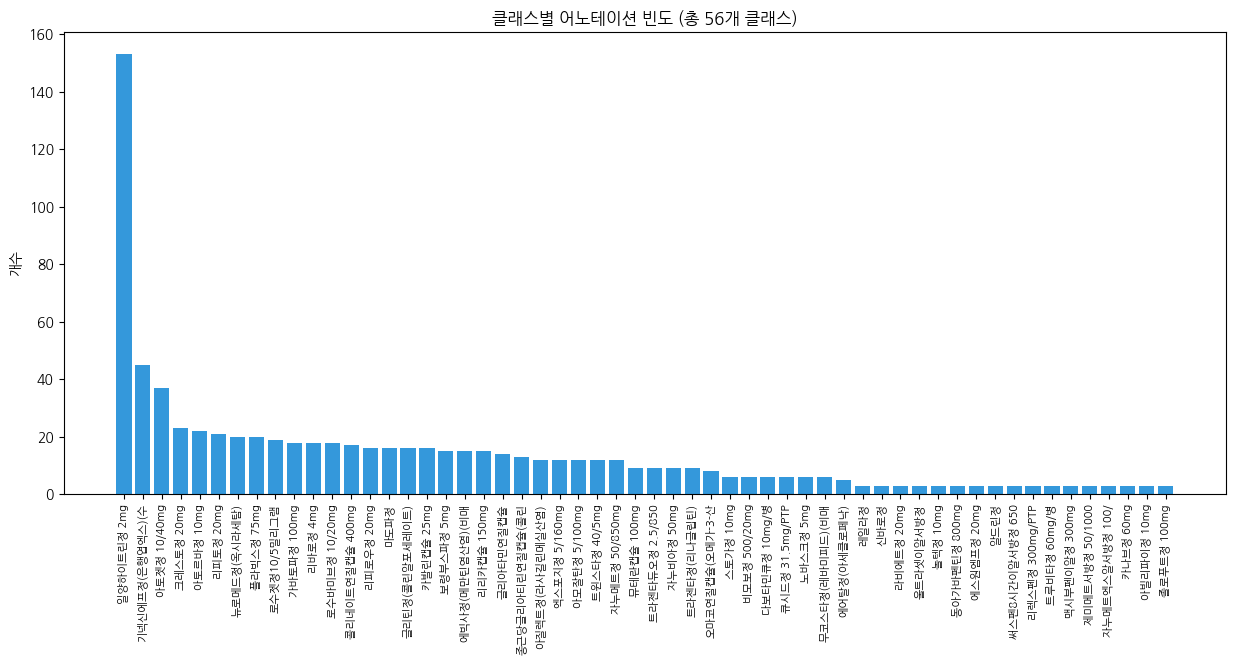

최다 클래스: 일양하이트린정 2mg (153개)
최소 클래스: 졸로푸트정 100mg (3개)
불균형 비율: 51.0배


In [5]:
class_counts = Counter(ann['category_id'] for ann in anns_data)
sorted_classes = sorted(class_counts.items(), key=lambda x: -x[1])

ids, counts = zip(*sorted_classes)
names = [categories[cid][:15] for cid in ids]

plt.figure(figsize=(15, 6))
plt.bar(names, counts, color='#3498db')
plt.xticks(rotation=90, fontsize=8)
plt.title(f"클래스별 어노테이션 빈도 (총 {len(categories)}개 클래스)")
plt.ylabel("개수")
plt.show()

print("최다 클래스:", categories[ids[0]], f"({counts[0]}개)")
print("최소 클래스:", categories[ids[-1]], f"({counts[-1]}개)")
print(f"불균형 비율: {counts[0]/counts[-1]:.1f}배")

## 3. 📐 바운딩 박스(BBox) 특성
알약이 이미지의 얼마나 빈 영역을 차지하는지, 형태는 어떠한지 분석합니다.

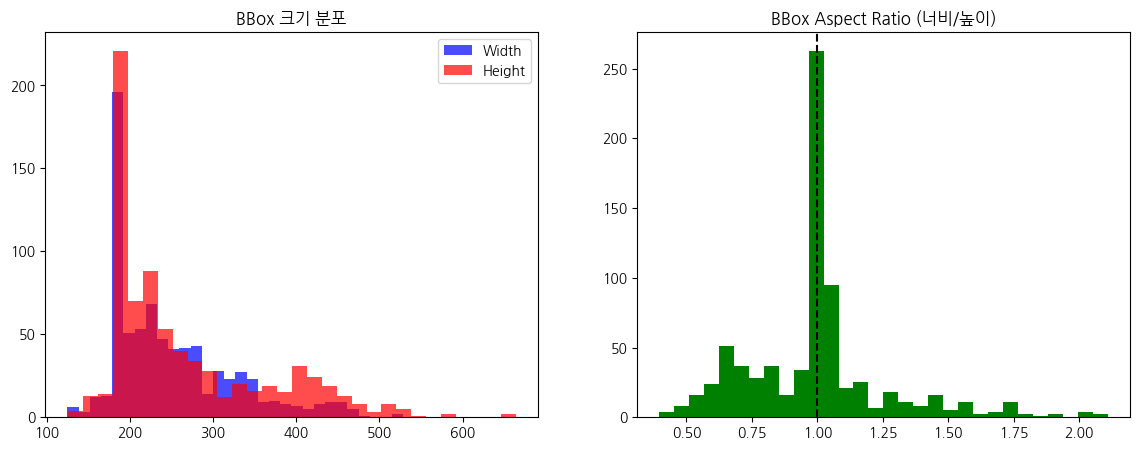

In [6]:
widths = [ann['bbox'][2] for ann in anns_data]
heights = [ann['bbox'][3] for ann in anns_data]
aspect_ratios = [w/h for w, h in zip(widths, heights)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(widths, bins=30, alpha=0.7, color='blue', label='Width')
axes[0].hist(heights, bins=30, alpha=0.7, color='red', label='Height')
axes[0].set_title("BBox 크기 분포")
axes[0].legend()

axes[1].hist(aspect_ratios, bins=30, color='green')
axes[1].axvline(1.0, color='black', linestyle='--')
axes[1].set_title("BBox Aspect Ratio (너비/높이)")
plt.show()

## 4. 시각적 검증 (Ground Truth Visualization)
라벨이 이미지 위에서 정확하게 표시되는지 샘플을 확인합니다.

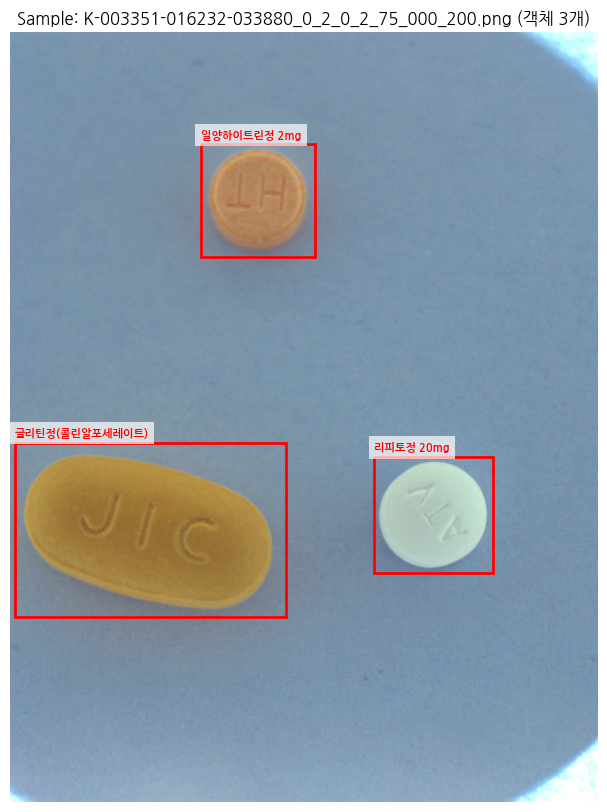

In [7]:
def plot_sample(img_id):
    img_meta = unique_imgs[img_id]
    img_path = TRAIN_IMG_DIR / img_meta['file_name']
    img = Image.open(img_path)
    
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.imshow(img)
    
    # 해당 이미지의 모든 어노테이션 필터링
    img_anns = [ann for ann in anns_data if ann['image_id'] == img_id]
    
    for ann in img_anns:
        x, y, w, h = ann['bbox']
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-10, categories[ann['category_id']], color='red', fontsize=8, weight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    
    plt.title(f"Sample: {img_meta['file_name']} (객체 {len(img_anns)}개)")
    plt.axis('off')
    plt.show()

# 랜덤 샘플 이미지 ID 선택
sample_id = sorted(unique_imgs.keys())[0]
plot_sample(sample_id)

## 5. 약 메타데이터 분포
모양, 색상, 배경 등 모델 학습에 방해가 되거나 도움이 될 환경 요소를 체크합니다.

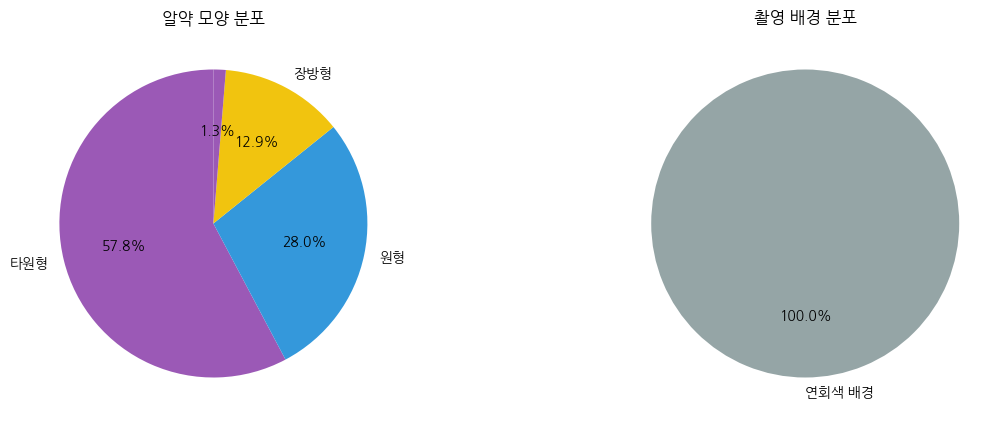

In [8]:
shapes = Counter(img.get('drug_shape', 'N/A') for img in unique_imgs.values())
backgrounds = Counter(img.get('back_color', 'N/A') for img in unique_imgs.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(shapes.values(), labels=shapes.keys(), autopct='%1.1f%%', startangle=90, colors=['#9b59b6', '#3498db', '#f1c40f'])
axes[0].set_title("알약 모양 분포")

axes[1].pie(backgrounds.values(), labels=backgrounds.keys(), autopct='%1.1f%%', startangle=90, colors=['#95a5a6', '#7f8c8d'])
axes[1].set_title("촬영 배경 분포")
plt.show()

## 최종 결론 및 전략 

### 1️.클래스 불균형 해결
- 51배 이상의 불균형이 존재하므로 일반적인 CrossEntropy는 위험합니다.
- **Focal Loss** 또는 **Class-weighted Loss** 적용 고려해봐야 합니다. 
- 데이터가 3개 내외인 소수 클래스는 전처리 과정에서 **Oversampling**이나 **Copy-Paste Augmentation** 필요하다고 생각이 듭니다. 

### 2.이미지 해상도 전략
- 이미지 해상도가 **976×1280**으로 고정되어 있습니다.
- 모델 입력 크기를 **1280**으로 잡거나, 작은 객체 감지를 위해 **800~1024** 이상을 유지하는 것이 유리할 것 같습니다. 

### 3️.배경 편향 대응
- 배경이 '연회색'으로 매우 균일합니다.
- 모델이 특정 배경색에 과적합(Overfitting)되지 않도록 **Background Substitution(배경 교체)** 또는 **Random Brightness/Contrast** 강화가 필요합니다.

### 4️.객체 크기 대응
- 알약이 이미지 전체 대비 큰 특징을 가지지 않습니다(평균 면적 비율 낮음).
- 작은 객체(Small Object) 검출 성능 향상을 위해 **FPN(Feature Pyramid Network)**이 강한 최신 YOLO 시리즈(v8, v11)가 적합합니다.